
#Cluster jerárquico

El objetivo del archivo es elaborar un cluster jerárquico. Para ello utilizaremos una base de datos de países del mundo. Adicionalmente, instalaremos en colab las librerías necesarias.

In [7]:
install.packages("dendextend")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘viridis’




In [2]:
library(readxl)
mundo<-read_excel("mundo2014ampliado.xlsx")


##Definición de variables- Business & data understanding

Por el teorema del patito feo sabemos que la elección de las variables a utilizar no es neutra, luego debemos ponernos en una posición u objetivo específico que nos guíe. Supongamos que somos un organismo multilateral con alguna capacidad de apoyo a los países americanos, y resulta de importancia focalizar la ayuda por grupos de países según sus necesidades. A partir de ello ¿qué variables escogería?

Si se piensa en que el objetivo es llevar una vida larga, sana, educada y en riqueza se podría decir que el PIB per cápita me habla de la riqueza actual (aunque quizás falte el índice GINI), la esperanza de vida me sirve para medir la vida larga, y el tiempo de escolarización puede ser un proxy de la educación. El crecimiento del PIB y la tasa de fertilidad son más discutibles, aunque el primero me habla de la dinámica actual del país y la segunda tiende a estar correlacionada con el desarrollo (Bryant, J., 2007). En cambio, me inclinaré por descartar las variables de población y PIB pues no me hablan de las necesidades específicas del país.
##Data preparation

Vamos entonces a seleccionar de la base de datos lo que necesitamos.

In [3]:
#extraer solo américa
america<-subset(mundo,mundo$america==1)
#extraer las variables que necesitamos y unirlas en una sola base de datos
americafin<-america[,c(3,4,7,8,9)]
#extraer los nombres de la variable y guardarlos como nombres de las filas
americalab<-america$Country
rownames(americafin)<-americalab

Warning message:
“Setting row names on a tibble is deprecated.”


Lo siguiente es calcular una métrica de distancia. Vamos a utilizar la distancia euclidea. Para ello primero tenemos que estandarizar los datos, con el fin de evitar el problema de las diferentes unidades de las variables.

In [4]:
#estandarizar
americafins<-scale(americafin)
#calcular la matriz de distancias
americadist<-dist(americafins,method="euclidean")

Con la matriz de distancias ya se puede obtener un cluster jerárquico.
##Modelado

Para crear los clústeres jerárquicos el siguiente paso es escoger un mecanismo de unión de los clusteres.

Vamos a revisar la unión completa (* complete linkage) y la única o single linkage*


---------------------
Welcome to dendextend version 1.16.0
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/questions/tagged/dendextend

	To suppress this message use:  suppressPackageStartupMessages(library(dendextend))
---------------------



Attaching package: ‘dendextend’


The following object is masked from ‘package:stats’:

    cutree




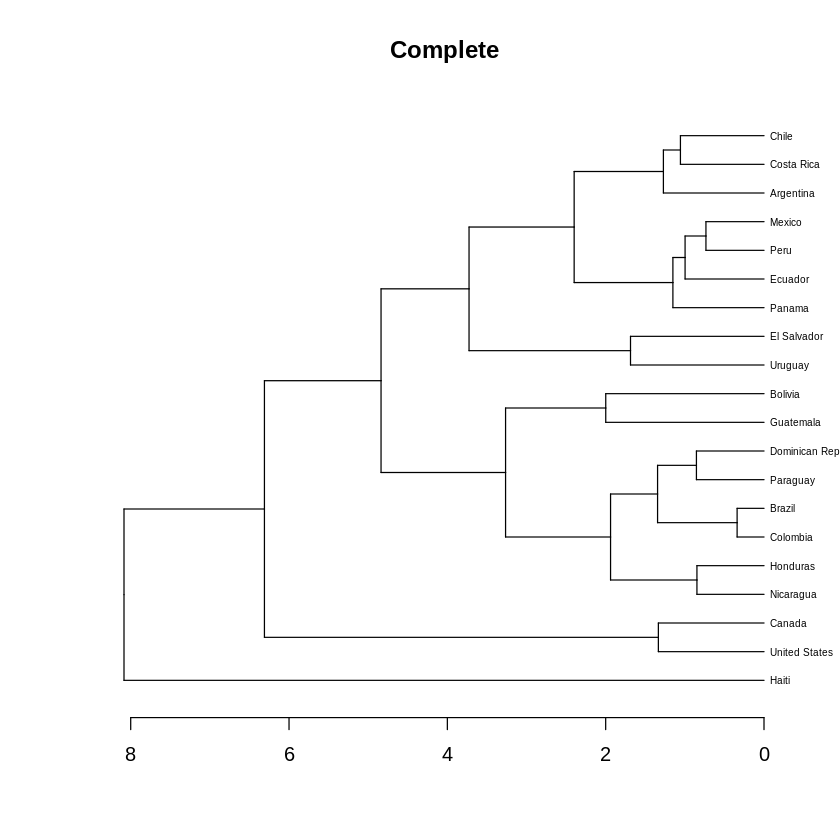

In [8]:
#cluster complete linkage
library(ggplot2)
library(dendextend)
#crear el cluster jerárquico. Por defecto es complete linkage
americacomplete<-hclust(americadist)
#algunos arreglos gráficos
grafdend<-as.dendrogram(americacomplete)
grafdend<-set(grafdend,"labels_cex",0.5)
#ver el resultado
plot(grafdend,horiz=TRUE, main="Complete")

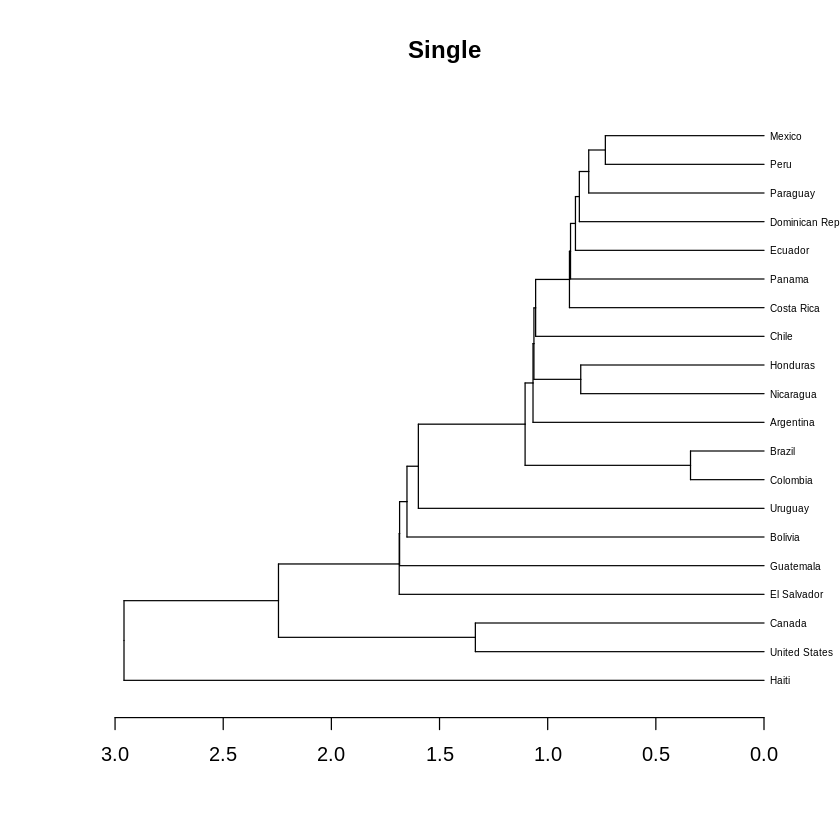

In [9]:
#cluster single linkage: proceso similar
americasingle<-hclust(americadist,method="single")
grafdends<-as.dendrogram(americasingle)
grafdends<-set(grafdends,"labels_cex",0.5)
plot(grafdends, horiz=TRUE, main="Single")

Se pueden observar diferencias interesantes entre los dos métodos.

El método complete busca hacer siempre grupos más compactos mientras single solo une por el punto más cercano. En los grupos iniciales y los finales el resultado tiende a ser el mismo, pero en los grupos intermedios se generan diferencias.

En nuestro caso, Haití es claramente un país diferente, mientras USA y Canadá hacen también un grupo aparte. La diferencia está en la forma en que se unen los demás países.

Argentina, por ejemplo, se clasifica en diferentes grupos. En single, Uruguay, Bolivia, Guatemala y El Salvador se unen lentamente al final al grupo, mientras que en complete se arman dos grupos (de Chile a Uruguay y de Bolivia a Nicaragua) que se unen al final. Si lo que queremos es grupos de países para una única estrategia de apoyo, quizás complete sea nuestra metodología.

Observe que, al no incluir la población, México y Brasil se ubican en ambos casos en lugares diferentes. México es más cercano a Perú, mientras que Brasil es más cercano a Colombia. Para ver las variables de influencia podemos hacer un heatmap:

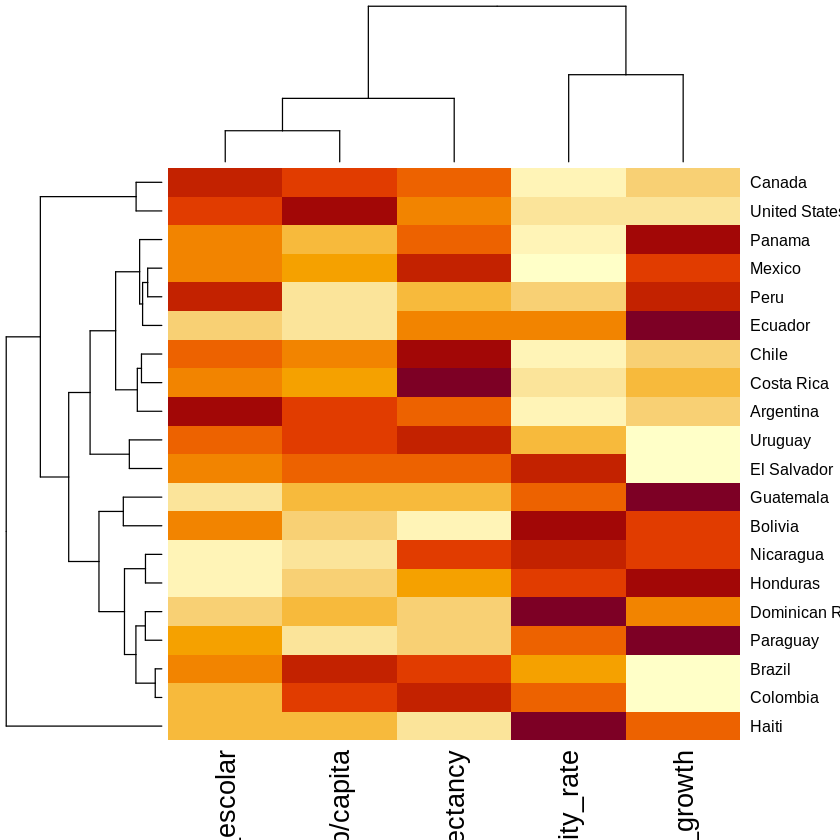

In [10]:
## Gráfico
heatmap(americafins,hclustfun=hclust)

Se puede observar que en la parte alta del dendrograma se agrupan países con menor tasa de fertilidad mientras que abajo tienen mayor tasa de fertilidad. El crecimiento de PIB también marca 4 o 5 grupos diferenciados dentro de las tasas de fertilidad.

Aunque al principio no hay que escoger un número de clusteres, al final es necesario hacerlo. En nuestro caso quizás 6 grupos sea una posiblidad (para dividir en 4 los demás países aparte de USA, Canadá y Haití)

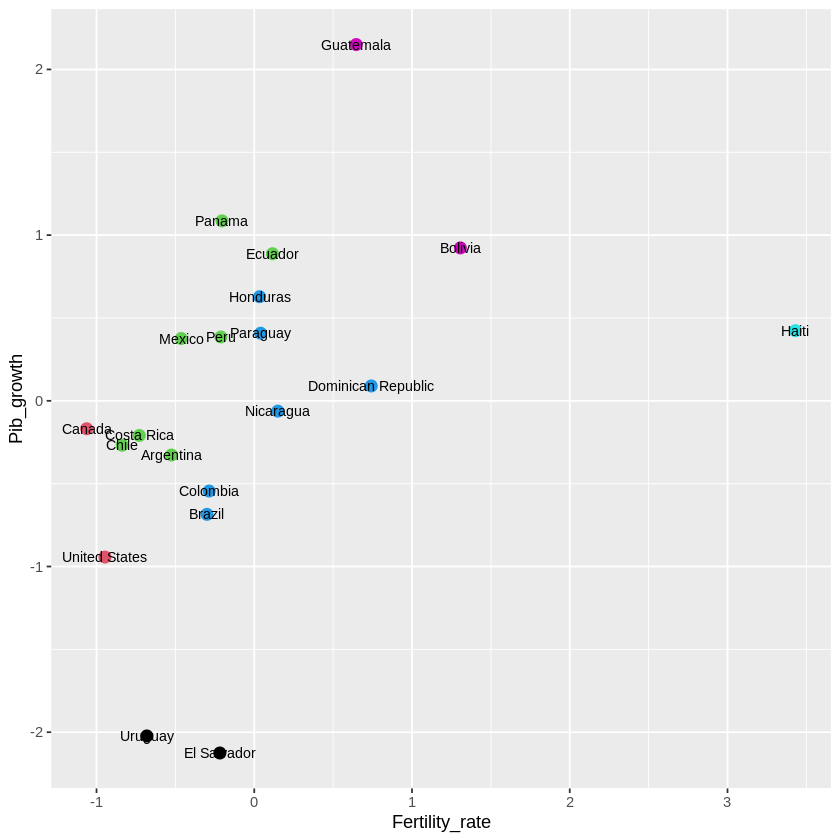

In [11]:
# cortar el dendograma a un nivel dado y guardar el grupo de pertenencia
americajcluster<-cutree(americacomplete,k=6)
#unir a la base de datos para analisis subsiguiente
americafins2<-as.data.frame(cbind(americafins,americajcluster))
#dejar la variable de grupo como factor
americafins2$americajcluster<-as.factor(americafins2$americajcluster)
#graficar
ggplot(aes(x=Fertility_rate, y=Pib_growth), data=americafins2)+geom_point(col=americajcluster,size=3)+geom_text(label=rownames(americafins2), size=3)

Los grupos entonces quedan perfilados en esas dos variables para una interpretación. Haití como grupo requiere una mirada inicial relacionada con sus tasas de fertilidad, mientras Uruguay y El Salvador requieren más apoyo (p.e, en innovación) para hacer crecer su PIB.
Evaluación

Por supuesto se pueden perfilar los grupos por otras variables, o como una combinación de todas. Al ser un modelo de aprendizaje no supervisado la evaluación no la da tan claramente un criterio algorítmico/estadístico, sino más bien el resultado para la organización.
Bibliografía

Bryant, J. Theories of fertility decline and the evidence from development indicators. Popul. Dev. Rev. 33, 101-127 (2007)